
# MovieLens Recommender Explorer Starter Notebook

This notebook builds a small, explainable recommendation pipeline in stages:

1. Load and inspect MovieLens data  
2. Filter to a manageable subset for prototyping  
3. Build a **user-based collaborative filtering** recommender using cosine similarity  
4. Build a **matrix factorization** recommender using truncated SVD  
5. Evaluate both with ranking and beyond-accuracy metrics  
6. Visualize recommendation outputs and compare trade-offs

This notebook is designed for iteration first, scale second. Once the pipeline works on a filtered subset, you can optimize or expand toward the full MovieLens-25M dataset.



## Cell 1: Imports and setup

We import the core libraries for data loading, matrix operations, similarity computation, dimensionality reduction, and evaluation. Don't forget to create the environment first. 


In [ ]:


import warnings
warnings.filterwarnings("ignore")

import time
import math
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import umap.umap_ as umap



## Cell 2: Set dataset path

Download and load the movielens dataset. (comment out the download once saved to your local env)
- `ratings.csv`
- `movies.csv`


In [ ]:
import os
import requests
import zipfile


# DOWNLOAD DATA
# URL for MovieLens 25M
url = "https://files.grouplens.org/datasets/movielens/ml-25m.zip"
zip_path = "ml-25m.zip"
extract_path = "ml-25m"

# # Download
print("Downloading MovieLens 25M...")
with requests.get(url, stream=True) as r:
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

print("Download complete!")

# Extract
print("Extracting...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

print("Done! Dataset available at ./ml-25m/") # COMMENT THE ABOVE LINES AFTER DONE DOWNLOADING INITIALLY!

# keep the below lines
ratings = pd.read_csv(f"{extract_path}/ratings.csv")
movies = pd.read_csv(f"{extract_path}/movies.csv")

print("ratings shape:", ratings.shape)
print("movies shape:", movies.shape)


ratings shape: (25000095, 4)
movies shape: (62423, 3)


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



## Cell 3: Basic dataset inspection

Before building recommenders, it helps to understand the dataset scale: number of users, number of movies, and rating distribution.


Unique users: 162541
Unique movies rated: 59047
Rating values: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)] ...


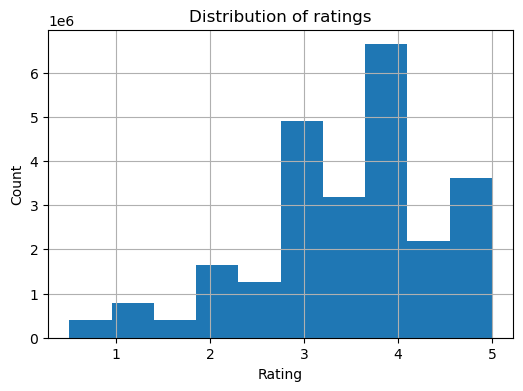

In [5]:

print("Unique users:", ratings["userId"].nunique())
print("Unique movies rated:", ratings["movieId"].nunique())
print("Rating values:", sorted(ratings["rating"].unique())[:10], "...")

ratings["rating"].hist(bins=10, figsize=(6,4))
plt.title("Distribution of ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()



## Cell 4: Filter to a prototyping subset

MovieLens-25M is large. For a first notebook, we reduce the dataset to:

- users with at least `MIN_USER_RATINGS` ratings
- movies with at least `MIN_MOVIE_RATINGS` ratings

This makes iteration much faster while preserving collaborative structure.


In [ ]:

# increasing these values reduces the dataset size we work with
MIN_USER_RATINGS = 3000
MIN_MOVIE_RATINGS =3000

user_counts = ratings["userId"].value_counts()
movie_counts = ratings["movieId"].value_counts()

active_users = user_counts[user_counts >= MIN_USER_RATINGS].index
popular_movies = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index

ratings_small = ratings[
    ratings["userId"].isin(active_users) &
    ratings["movieId"].isin(popular_movies)
].copy()

print("Original ratings:", len(ratings))
print("Filtered ratings:", len(ratings_small))
print("Filtered users:", ratings_small["userId"].nunique())
print("Filtered movies:", ratings_small["movieId"].nunique())


Original ratings: 25000095
Filtered ratings: 151473
Filtered users: 124
Filtered movies: 1830



## Cell 5: Keep only users with enough train/test signal

For top-N evaluation, each user needs enough interactions so we can hold some ratings out for testing.  
We keep users with at least `MIN_TOTAL_RATINGS_PER_USER` ratings after filtering.


In [7]:

MIN_TOTAL_RATINGS_PER_USER = 20

eligible_user_counts = ratings_small["userId"].value_counts()
eligible_users = eligible_user_counts[eligible_user_counts >= MIN_TOTAL_RATINGS_PER_USER].index

ratings_small = ratings_small[ratings_small["userId"].isin(eligible_users)].copy()

print("Users after eligibility filter:", ratings_small["userId"].nunique())
print("Movies after eligibility filter:", ratings_small["movieId"].nunique())
print("Ratings after eligibility filter:", len(ratings_small))


Users after eligibility filter: 124
Movies after eligibility filter: 1830
Ratings after eligibility filter: 151473



## Cell 6: Train/test split per user

We do a user-level split so every user appears in both train and test:

- sort each user's ratings by timestamp
- keep the last `TEST_FRACTION` as test
- use the earlier interactions as train

This better matches a recommendation setting than a random global split.


In [8]:

TEST_FRACTION = 0.2
MIN_TEST_ITEMS = 2

def train_test_split_by_user(df, test_fraction=0.2, min_test_items=2):
    train_parts = []
    test_parts = []

    for user_id, group in df.groupby("userId"):
        group = group.sort_values("timestamp")
        n = len(group)
        n_test = max(min_test_items, int(math.ceil(n * test_fraction)))
        n_test = min(n_test, n - 1)  # keep at least one train interaction

        test_group = group.iloc[-n_test:]
        train_group = group.iloc[:-n_test]

        train_parts.append(train_group)
        test_parts.append(test_group)

    train_df = pd.concat(train_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)
    return train_df, test_df

train_df, test_df = train_test_split_by_user(
    ratings_small,
    test_fraction=TEST_FRACTION,
    min_test_items=MIN_TEST_ITEMS
)

print("Train ratings:", len(train_df))
print("Test ratings:", len(test_df))
print("Train users:", train_df["userId"].nunique())
print("Test users:", test_df["userId"].nunique())


Train ratings: 121130
Test ratings: 30343
Train users: 124
Test users: 124



## Cell 7: Define relevance for top-N recommendation

We convert ratings into binary relevance for evaluation.  
A movie is considered **relevant** if the held-out rating is at least `RELEVANCE_THRESHOLD`.


In [9]:

RELEVANCE_THRESHOLD = 4.0

test_relevant = test_df[test_df["rating"] >= RELEVANCE_THRESHOLD].copy()

relevant_items_by_user = (
    test_relevant.groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

print("Users with at least one relevant held-out item:", len(relevant_items_by_user))


Users with at least one relevant held-out item: 123



## Cell 8: Build user/movie index mappings and the train matrix

Both recommenders will use the same train interaction matrix.  
Rows are users, columns are movies, and values are ratings.


In [10]:

all_train_users = np.sort(train_df["userId"].unique())
all_train_movies = np.sort(train_df["movieId"].unique())

user_to_index = {u: i for i, u in enumerate(all_train_users)}
index_to_user = {i: u for u, i in user_to_index.items()}

movie_to_index = {m: i for i, m in enumerate(all_train_movies)}
index_to_movie = {i: m for m, i in movie_to_index.items()}

row_idx = train_df["userId"].map(user_to_index).values
col_idx = train_df["movieId"].map(movie_to_index).values
data = train_df["rating"].astype(float).values

train_matrix = csr_matrix(
    (data, (row_idx, col_idx)),
    shape=(len(all_train_users), len(all_train_movies))
)

print("Train matrix shape:", train_matrix.shape)
print("Train matrix nnz:", train_matrix.nnz)


Train matrix shape: (124, 1830)
Train matrix nnz: 121130



## Cell 9: Create helper views of the train data

These structures make recommendation and evaluation easier:

- dense user-movie DataFrame for explainable CF
- sets of movies seen in train for filtering
- movie metadata joins


In [11]:

train_pivot = train_df.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

train_seen_items_by_user = (
    train_df.groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

movies_meta = movies[["movieId", "title", "genres"]].copy()

print(train_pivot.shape)
train_pivot.head()


(124, 1830)


movieId,1,2,3,5,6,7,9,10,11,12,...,168250,168252,171763,174055,176371,177593,177765,179819,187593,195159
userId,,,,,,,,,,,,,,,,,,,,,
548,4.5,4.0,NaN,NaN,NaN,NaN,3.0,3.5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1748,4.5,3.0,2.5,4.0,4.0,3.5,NaN,4.5,4.5,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2177,4.0,NaN,4.0,3.0,3.0,4.0,NaN,4.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8619,NaN,2.5,2.5,2.0,4.5,4.0,NaN,3.0,2.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12244,4.0,4.5,NaN,NaN,4.0,NaN,3.0,3.5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## Cell 10: User-based collaborative filtering with cosine similarity

This is a **memory-based collaborative filtering** method.

Idea:
- compare users by cosine similarity over their rating vectors
- find the nearest neighbors of the target user
- aggregate neighbors' high-rated unseen movies into a ranked list


In [12]:

train_pivot_filled = train_pivot.fillna(0)

user_similarity = cosine_similarity(train_pivot_filled)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=train_pivot_filled.index,
    columns=train_pivot_filled.index
)

user_similarity_df.iloc[:5, :5]


userId,548,1748,2177,8619,12244
userId,,,,,
548,1.000000,0.530379,0.423546,0.446762,0.782571
1748,0.530379,1.000000,0.690752,0.659582,0.542128
2177,0.423546,0.690752,1.000000,0.765437,0.391823
8619,0.446762,0.659582,0.765437,1.000000,0.439994
12244,0.782571,0.542128,0.391823,0.439994,1.000000



## Cell 11: Recommendation function for user-based cosine CF

The recommender:
- finds the most similar users
- looks at their strong ratings
- excludes movies already seen by the target user
- ranks movies by similarity-weighted score


In [13]:

def recommend_user_based(
    target_user_id,
    train_matrix_df,
    similarity_df,
    seen_items,
    top_k_neighbors=20,
    top_n=10,
    min_neighbor_rating=4.0
):
    if target_user_id not in train_matrix_df.index:
        return pd.DataFrame(columns=["movieId", "score", "neighbor_count"])

    sim_scores = similarity_df.loc[target_user_id].drop(target_user_id)
    top_neighbors = sim_scores.sort_values(ascending=False).head(top_k_neighbors)

    user_seen = seen_items.get(target_user_id, set())
    rec_scores = {}

    for neighbor_id, sim in top_neighbors.items():
        neighbor_ratings = train_matrix_df.loc[neighbor_id].dropna()
        liked = neighbor_ratings[neighbor_ratings >= min_neighbor_rating]

        for movie_id, rating in liked.items():
            if movie_id in user_seen:
                continue

            if movie_id not in rec_scores:
                rec_scores[movie_id] = {"weighted_sum": 0.0, "sim_sum": 0.0, "neighbor_count": 0}

            rec_scores[movie_id]["weighted_sum"] += sim * rating
            rec_scores[movie_id]["sim_sum"] += abs(sim)
            rec_scores[movie_id]["neighbor_count"] += 1

    rows = []
    for movie_id, vals in rec_scores.items():
        if vals["sim_sum"] > 0:
            score = vals["weighted_sum"] / vals["sim_sum"]
            rows.append([movie_id, score, vals["neighbor_count"]])

    recs = pd.DataFrame(rows, columns=["movieId", "score", "neighbor_count"])
    if recs.empty:
        return recs

    return recs.sort_values(["score", "neighbor_count"], ascending=[False, False]).head(top_n)



## Cell 12: Build a matrix factorization model with truncated SVD

This is a simple **model-based collaborative filtering** baseline.

We factor the user-item matrix into a lower-dimensional latent space:
- user factors
- movie factors

We then reconstruct preference scores for unseen items.


In [14]:

N_FACTORS = 50

svd = TruncatedSVD(n_components=N_FACTORS, random_state=42)

user_factors = svd.fit_transform(train_matrix)
item_factors = svd.components_.T  # shape: [num_movies, num_factors]

print("User factors shape:", user_factors.shape)
print("Item factors shape:", item_factors.shape)
print("Explained variance ratio sum:", svd.explained_variance_ratio_.sum())


User factors shape: (124, 50)
Item factors shape: (1830, 50)
Explained variance ratio sum: 0.7541247027669136


## Cell 12B: Joint UMAP projection of user and movie embeddings

Matrix factorization places **users and movies in the same latent factor space**.  
To visualize them together, we must run UMAP on the **combined** embedding matrix instead of projecting users and movies separately.

This gives us a shared 2D map where:
- each movie is a point
- each user is a point
- nearby users and movies indicate stronger preference alignment in the learned latent space


In [15]:
combined_embeddings = np.vstack([user_factors, item_factors])
num_users = user_factors.shape[0]
num_movies = item_factors.shape[0]

joint_umap_reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

joint_umap_2d = joint_umap_reducer.fit_transform(combined_embeddings)

user_umap_2d = joint_umap_2d[:num_users]
movie_umap_2d = joint_umap_2d[num_users:]

user_embedding_viz = pd.DataFrame({
    "userId": [index_to_user[i] for i in range(num_users)],
    "umap_x": user_umap_2d[:, 0],
    "umap_y": user_umap_2d[:, 1],
})

movie_embedding_viz = pd.DataFrame({
    "movieId": [index_to_movie[i] for i in range(num_movies)],
    "umap_x": movie_umap_2d[:, 0],
    "umap_y": movie_umap_2d[:, 1],
})

movie_embedding_viz = movie_embedding_viz.merge(
    movies_meta[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
)

movie_embedding_viz["main_genre"] = movie_embedding_viz["genres"].fillna("Unknown").apply(
    lambda g: g.split("|")[0] if g and g != "(no genres listed)" else "Unknown"
)

print("Joint UMAP shape:", joint_umap_2d.shape)
print("User visualization table shape:", user_embedding_viz.shape)
print("Movie visualization table shape:", movie_embedding_viz.shape)
movie_embedding_viz.head()


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Joint UMAP shape: (1954, 2)
User visualization table shape: (124, 3)
Movie visualization table shape: (1830, 6)


,movieId,umap_x,umap_y,title,genres,main_genre
0,1,-3.842737,9.133670,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure
1,2,-0.959687,7.236958,Jumanji (1995),Adventure|Children|Fantasy,Adventure
2,3,-3.137514,8.788130,Grumpier Old Men (1995),Comedy|Romance,Comedy
3,5,-3.417592,8.326483,Father of the Bride Part II (1995),Comedy,Comedy
4,6,-0.719108,8.492219,Heat (1995),Action|Crime|Thriller,Action



## Cell 13: Recommendation function for matrix factorization

For a target user:
- take the dot product between the user's latent vector and all item vectors
- remove already-seen movies
- return the top-N remaining items


In [16]:

def recommend_mf(
    target_user_id,
    user_to_index,
    index_to_movie,
    user_factors,
    item_factors,
    seen_items,
    top_n=10
):
    if target_user_id not in user_to_index:
        return pd.DataFrame(columns=["movieId", "score"])

    user_idx = user_to_index[target_user_id]
    scores = user_factors[user_idx] @ item_factors.T

    user_seen = seen_items.get(target_user_id, set())

    rows = []
    for movie_idx, score in enumerate(scores):
        movie_id = index_to_movie[movie_idx]
        if movie_id in user_seen:
            continue
        rows.append((movie_id, float(score)))

    recs = pd.DataFrame(rows, columns=["movieId", "score"])
    if recs.empty:
        return recs

    return recs.sort_values("score", ascending=False).head(top_n)



## Cell 14: Pick an example user and inspect recommendations

This cell generates recommendations from both approaches for one user, so you can qualitatively inspect differences before running full evaluation.


In [17]:

example_user_id = list(relevant_items_by_user.keys())[0]

user_cf_recs = recommend_user_based(
    target_user_id=example_user_id,
    train_matrix_df=train_pivot,
    similarity_df=user_similarity_df,
    seen_items=train_seen_items_by_user,
    top_k_neighbors=20,
    top_n=10,
    min_neighbor_rating=4.0
).merge(movies_meta, on="movieId", how="left")

mf_recs = recommend_mf(
    target_user_id=example_user_id,
    user_to_index=user_to_index,
    index_to_movie=index_to_movie,
    user_factors=user_factors,
    item_factors=item_factors,
    seen_items=train_seen_items_by_user,
    top_n=10
).merge(movies_meta, on="movieId", how="left")

print("Example user:", example_user_id)
print("\nUser-based CF recommendations:")
display(user_cf_recs[["movieId", "title", "genres", "score"]])

print("\nMatrix factorization recommendations:")
display(mf_recs[["movieId", "title", "genres", "score"]])


Example user: 548

User-based CF recommendations:


,movieId,title,genres,score
0,1274,Akira (1988),Action|Adventure|Animation|Sci-Fi,5.0
1,1147,When We Were Kings (1996),Documentary,5.0
2,193,Showgirls (1995),Drama,5.0
3,143355,Wonder Woman (2017),Action|Adventure|Fantasy,5.0
4,968,Night of the Living Dead (1968),Horror|Sci-Fi|Thriller,5.0
5,1278,Young Frankenstein (1974),Comedy|Fantasy,5.0
6,1356,Star Trek: First Contact (1996),Action|Adventure|Sci-Fi|Thriller,5.0
7,2108,L.A. Story (1991),Comedy|Romance,5.0
8,2948,From Russia with Love (1963),Action|Adventure|Thriller,5.0
9,2949,Dr. No (1962),Action|Adventure|Thriller,5.0



Matrix factorization recommendations:


,movieId,title,genres,score
0,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,3.027847
1,4848,Mulholland Drive (2001),Crime|Drama|Film-Noir|Mystery|Thriller,2.965295
2,2161,"NeverEnding Story, The (1984)",Adventure|Children|Fantasy,2.948325
3,1732,"Big Lebowski, The (1998)",Comedy|Crime,2.885650
4,2959,Fight Club (1999),Action|Crime|Drama|Thriller,2.789165
5,46530,Superman Returns (2006),Action|Adventure|Sci-Fi|IMAX,2.758585
6,2985,RoboCop (1987),Action|Crime|Drama|Sci-Fi|Thriller,2.721364
7,3087,Scrooged (1988),Comedy|Fantasy|Romance,2.718720
8,56171,"Golden Compass, The (2007)",Adventure|Children|Fantasy,2.698877
9,3809,What About Bob? (1991),Comedy,2.697866


## Cell 14B: Overlay MF and user-based CF recommendations on the joint UMAP map

This visualization places the **example user**, their **seen movies**, and the recommendation outputs from **both algorithms** in the same 2D embedding space.

Interpretation:
- gray points = all other movies
- green points = movies the user already rated in the training data
- red circles = matrix factorization recommendations
- blue squares = user-based collaborative filtering recommendations
- purple points = movies recommended by both methods
- black X = the selected user

This makes it easier to compare how the two recommenders behave geometrically:
- **MF** tends to recommend movies close to the user's latent preference direction
- **User-based CF** tends to recommend movies that are supported by similar users' histories
- overlap between the two suggests agreement across methods


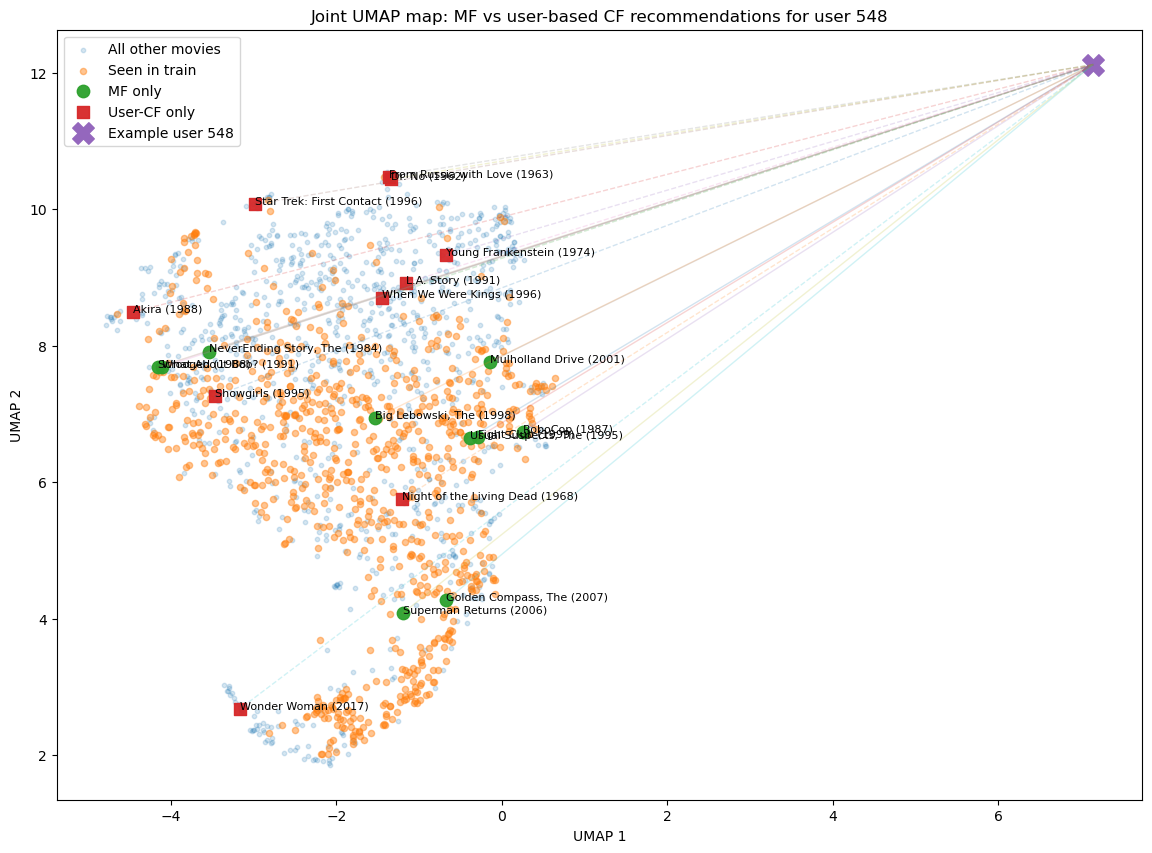

In [18]:
mf_recommended_movie_ids = set(mf_recs["movieId"])
cf_recommended_movie_ids = set(user_cf_recs["movieId"])
seen_movie_ids = train_seen_items_by_user.get(example_user_id, set())

plot_movies = movie_embedding_viz.copy()
plot_movies["is_seen"] = plot_movies["movieId"].isin(seen_movie_ids)
plot_movies["is_mf_rec"] = plot_movies["movieId"].isin(mf_recommended_movie_ids)
plot_movies["is_cf_rec"] = plot_movies["movieId"].isin(cf_recommended_movie_ids)
plot_movies["is_overlap_rec"] = plot_movies["is_mf_rec"] & plot_movies["is_cf_rec"]

example_user_point = user_embedding_viz[user_embedding_viz["userId"] == example_user_id].iloc[0]

background_movies = plot_movies[
    ~plot_movies["is_seen"] &
    ~plot_movies["is_mf_rec"] &
    ~plot_movies["is_cf_rec"]
]
seen_movies = plot_movies[
    plot_movies["is_seen"] &
    ~plot_movies["is_mf_rec"] &
    ~plot_movies["is_cf_rec"]
]
mf_only_movies = plot_movies[
    plot_movies["is_mf_rec"] &
    ~plot_movies["is_cf_rec"]
]
cf_only_movies = plot_movies[
    plot_movies["is_cf_rec"] &
    ~plot_movies["is_mf_rec"]
]
overlap_movies = plot_movies[plot_movies["is_overlap_rec"]]

plt.figure(figsize=(14, 10))

plt.scatter(
    background_movies["umap_x"],
    background_movies["umap_y"],
    s=10,
    alpha=0.18,
    label="All other movies"
)

if not seen_movies.empty:
    plt.scatter(
        seen_movies["umap_x"],
        seen_movies["umap_y"],
        s=20,
        alpha=0.45,
        label="Seen in train"
    )

if not mf_only_movies.empty:
    plt.scatter(
        mf_only_movies["umap_x"],
        mf_only_movies["umap_y"],
        s=80,
        alpha=0.95,
        marker="o",
        label="MF only"
    )
    for _, row in mf_only_movies.iterrows():
        plt.text(row["umap_x"], row["umap_y"], row["title"], fontsize=8)

if not cf_only_movies.empty:
    plt.scatter(
        cf_only_movies["umap_x"],
        cf_only_movies["umap_y"],
        s=80,
        alpha=0.95,
        marker="s",
        label="User-CF only"
    )
    for _, row in cf_only_movies.iterrows():
        plt.text(row["umap_x"], row["umap_y"], row["title"], fontsize=8)

if not overlap_movies.empty:
    plt.scatter(
        overlap_movies["umap_x"],
        overlap_movies["umap_y"],
        s=110,
        alpha=1.0,
        marker="D",
        label="Recommended by both"
    )
    for _, row in overlap_movies.iterrows():
        plt.text(row["umap_x"], row["umap_y"], row["title"], fontsize=8)

plt.scatter(
    [example_user_point["umap_x"]],
    [example_user_point["umap_y"]],
    s=240,
    marker="X",
    label=f"Example user {example_user_id}"
)

for _, row in mf_only_movies.iterrows():
    plt.plot(
        [example_user_point["umap_x"], row["umap_x"]],
        [example_user_point["umap_y"], row["umap_y"]],
        alpha=0.20,
        linewidth=1
    )

for _, row in cf_only_movies.iterrows():
    plt.plot(
        [example_user_point["umap_x"], row["umap_x"]],
        [example_user_point["umap_y"], row["umap_y"]],
        alpha=0.20,
        linewidth=1,
        linestyle="--"
    )

for _, row in overlap_movies.iterrows():
    plt.plot(
        [example_user_point["umap_x"], row["umap_x"]],
        [example_user_point["umap_y"], row["umap_y"]],
        alpha=0.35,
        linewidth=1.5
    )

plt.title(f"Joint UMAP map: MF vs user-based CF recommendations for user {example_user_id}")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()


## Cell 14C: Inspect movie structure by genre in the same UMAP space

This plot colors movies by their primary genre so you can compare the **learned collaborative signal** with known movie metadata.
If genres cluster together, that suggests the matrix factorization model learned meaningful structure from user ratings.


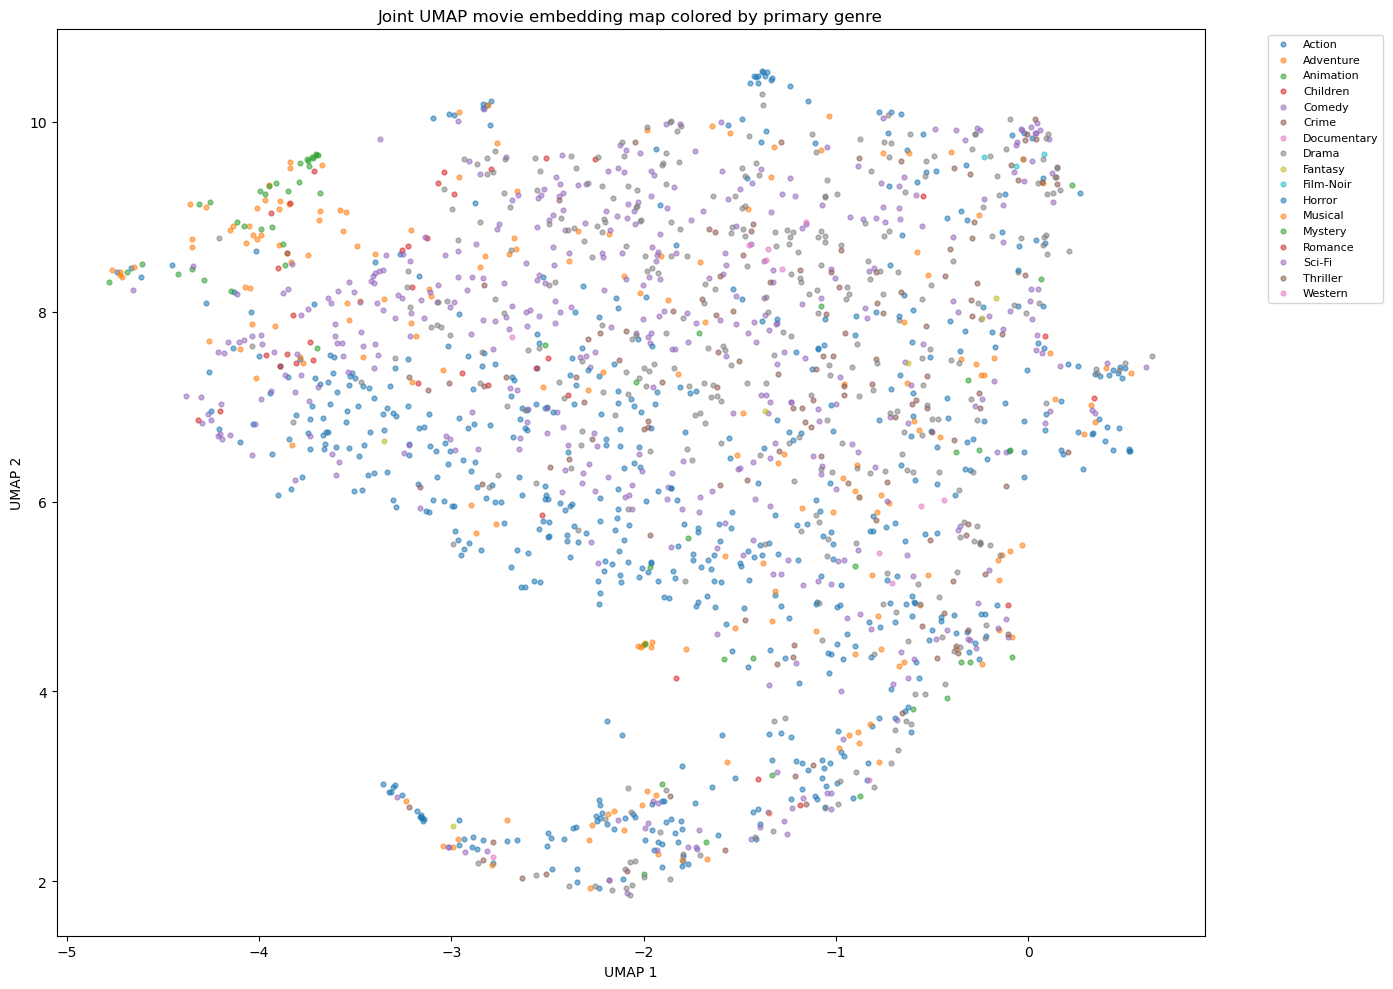

In [19]:
plt.figure(figsize=(14, 10))

for genre in sorted(movie_embedding_viz["main_genre"].dropna().unique()):
    subset = movie_embedding_viz[movie_embedding_viz["main_genre"] == genre]
    plt.scatter(
        subset["umap_x"],
        subset["umap_y"],
        s=12,
        alpha=0.55,
        label=genre
    )

plt.title("Joint UMAP movie embedding map colored by primary genre")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()



## Cell 15: Visualize one user's recommendations

We compare the recommendation scores from user-based CF and matrix factorization for the example user.


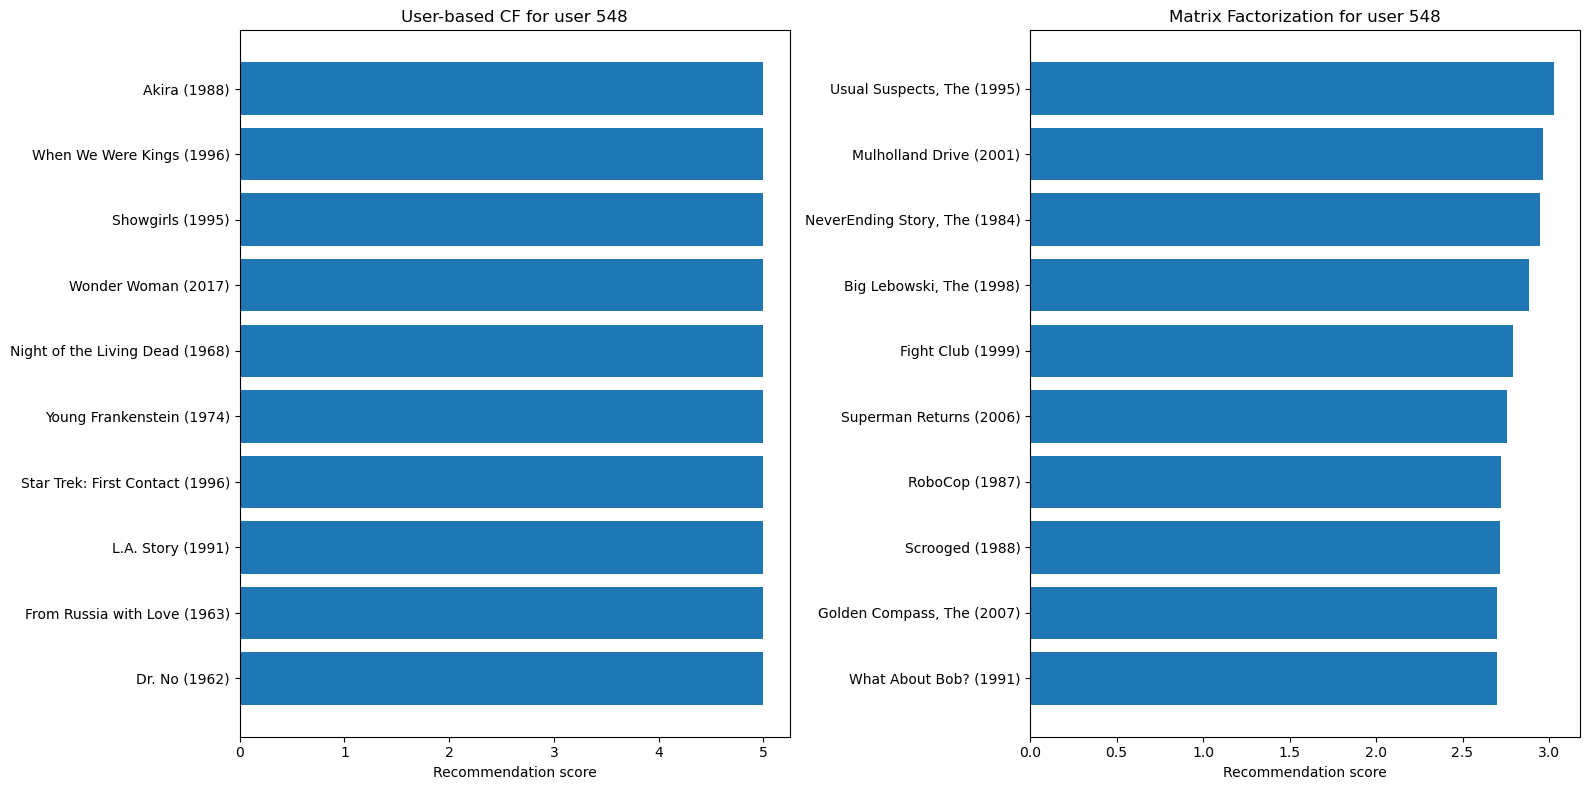

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

if not user_cf_recs.empty:
    axes[0].barh(
        user_cf_recs["title"].iloc[::-1],
        user_cf_recs["score"].iloc[::-1]
    )
    axes[0].set_title(f"User-based CF for user {example_user_id}")
    axes[0].set_xlabel("Recommendation score")

if not mf_recs.empty:
    axes[1].barh(
        mf_recs["title"].iloc[::-1],
        mf_recs["score"].iloc[::-1]
    )
    axes[1].set_title(f"Matrix Factorization for user {example_user_id}")
    axes[1].set_xlabel("Recommendation score")

plt.tight_layout()
plt.show()



## Cell 16: Genre-profile helper functions for diversity analysis

To compare algorithms beyond accuracy, we need a simple diversity proxy.  
We will use **genre overlap** between recommended movies.

This is not the only way to measure diversity, but it is easy to interpret in a first notebook.


In [21]:

movie_genres = movies_meta.set_index("movieId")["genres"].fillna("").to_dict()

def genre_set(movie_id):
    g = movie_genres.get(movie_id, "")
    if not g or g == "(no genres listed)":
        return set()
    return set(g.split("|"))

def jaccard_similarity(set_a, set_b):
    if not set_a and not set_b:
        return 1.0
    union = set_a | set_b
    if not union:
        return 0.0
    return len(set_a & set_b) / len(union)

def intra_list_diversity(movie_ids):
    if len(movie_ids) < 2:
        return 0.0

    sims = []
    for i in range(len(movie_ids)):
        for j in range(i + 1, len(movie_ids)):
            s1 = genre_set(movie_ids[i])
            s2 = genre_set(movie_ids[j])
            sims.append(jaccard_similarity(s1, s2))

    if not sims:
        return 0.0

    return 1.0 - np.mean(sims)



## Cell 17: Popularity metadata for bias analysis

A simple popularity-bias proxy is the average train-set popularity of recommended movies.  
Higher values mean the algorithm tends to recommend more popular titles.


In [22]:

movie_popularity = train_df["movieId"].value_counts().to_dict()

def avg_recommendation_popularity(movie_ids):
    if not movie_ids:
        return 0.0
    return float(np.mean([movie_popularity.get(m, 0) for m in movie_ids]))



## Cell 18: Ranking metric functions

We compute standard top-N recommendation metrics:

- Precision@K
- Recall@K
- NDCG@K

We also compute:
- catalog coverage
- intra-list diversity
- average recommended-item popularity
- average per-user latency


In [23]:

def precision_at_k(recommended, relevant, k):
    if k == 0:
        return 0.0
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & relevant)
    return hits / k

def recall_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & relevant)
    return hits / len(relevant)

def dcg_at_k(recommended, relevant, k):
    score = 0.0
    for i, movie_id in enumerate(recommended[:k], start=1):
        if movie_id in relevant:
            score += 1.0 / math.log2(i + 1)
    return score

def ndcg_at_k(recommended, relevant, k):
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    ideal = sum(1.0 / math.log2(i + 1) for i in range(1, ideal_hits + 1))
    actual = dcg_at_k(recommended, relevant, k)
    return actual / ideal



## Cell 19: Evaluation driver for a recommender

This function:
- iterates over evaluable users
- generates recommendations
- compares them with held-out relevant items
- aggregates metrics across users


In [24]:

def evaluate_recommender(
    algorithm_name,
    user_ids,
    relevant_items_by_user,
    recommender_fn,
    k=10
):
    precisions = []
    recalls = []
    ndcgs = []
    diversities = []
    popularities = []
    latencies = []
    all_recommended_items = set()

    evaluated_users = 0

    for user_id in user_ids:
        relevant = relevant_items_by_user.get(user_id, set())
        if not relevant:
            continue

        start = time.perf_counter()
        recs = recommender_fn(user_id, k)
        latency = time.perf_counter() - start

        if recs is None or recs.empty:
            continue

        recommended_ids = recs["movieId"].tolist()[:k]
        if len(recommended_ids) == 0:
            continue

        evaluated_users += 1
        all_recommended_items.update(recommended_ids)

        precisions.append(precision_at_k(recommended_ids, relevant, k))
        recalls.append(recall_at_k(recommended_ids, relevant, k))
        ndcgs.append(ndcg_at_k(recommended_ids, relevant, k))
        diversities.append(intra_list_diversity(recommended_ids))
        popularities.append(avg_recommendation_popularity(recommended_ids))
        latencies.append(latency)

    coverage = len(all_recommended_items) / len(all_train_movies) if len(all_train_movies) > 0 else 0.0

    return {
        "algorithm": algorithm_name,
        "users_evaluated": evaluated_users,
        "Precision@K": np.mean(precisions) if precisions else 0.0,
        "Recall@K": np.mean(recalls) if recalls else 0.0,
        "NDCG@K": np.mean(ndcgs) if ndcgs else 0.0,
        "Coverage": coverage,
        "IntraListDiversity": np.mean(diversities) if diversities else 0.0,
        "AvgRecPopularity": np.mean(popularities) if popularities else 0.0,
        "AvgLatencySec": np.mean(latencies) if latencies else 0.0
    }



## Cell 20: Wrap each recommender in a common interface

Both algorithms now expose the same simple interface:

`recommender(user_id, k) -> DataFrame with movieId and score`


In [25]:

def user_cf_wrapper(user_id, k):
    return recommend_user_based(
        target_user_id=user_id,
        train_matrix_df=train_pivot,
        similarity_df=user_similarity_df,
        seen_items=train_seen_items_by_user,
        top_k_neighbors=20,
        top_n=k,
        min_neighbor_rating=4.0
    )

def mf_wrapper(user_id, k):
    return recommend_mf(
        target_user_id=user_id,
        user_to_index=user_to_index,
        index_to_movie=index_to_movie,
        user_factors=user_factors,
        item_factors=item_factors,
        seen_items=train_seen_items_by_user,
        top_n=k
    )



## Cell 21: Run the comparison

We evaluate both algorithms on the same users and compare:

- Precision@K
- Recall@K
- NDCG@K
- Coverage
- Diversity
- Popularity bias proxy
- Query latency


In [26]:

K = 10
eval_users = sorted(set(train_df["userId"].unique()) & set(relevant_items_by_user.keys()))

user_cf_results = evaluate_recommender(
    algorithm_name="User-based Cosine CF",
    user_ids=eval_users,
    relevant_items_by_user=relevant_items_by_user,
    recommender_fn=user_cf_wrapper,
    k=K
)

mf_results = evaluate_recommender(
    algorithm_name="Matrix Factorization (Truncated SVD)",
    user_ids=eval_users,
    relevant_items_by_user=relevant_items_by_user,
    recommender_fn=mf_wrapper,
    k=K
)

results_df = pd.DataFrame([user_cf_results, mf_results])
results_df


,algorithm,users_evaluated,Precision@K,Recall@K,NDCG@K,Coverage,IntraListDiversity,AvgRecPopularity,AvgLatencySec
0,User-based Cosine CF,123,0.111382,0.013994,0.102325,0.160109,0.819127,55.500000,0.004119
1,Matrix Factorization (Truncated SVD),123,0.298374,0.061394,0.319926,0.430601,0.794682,73.893496,0.000575



## Cell 22: Visual comparison of evaluation metrics

This chart makes it easier to compare the trade-offs between the two recommendation approaches.


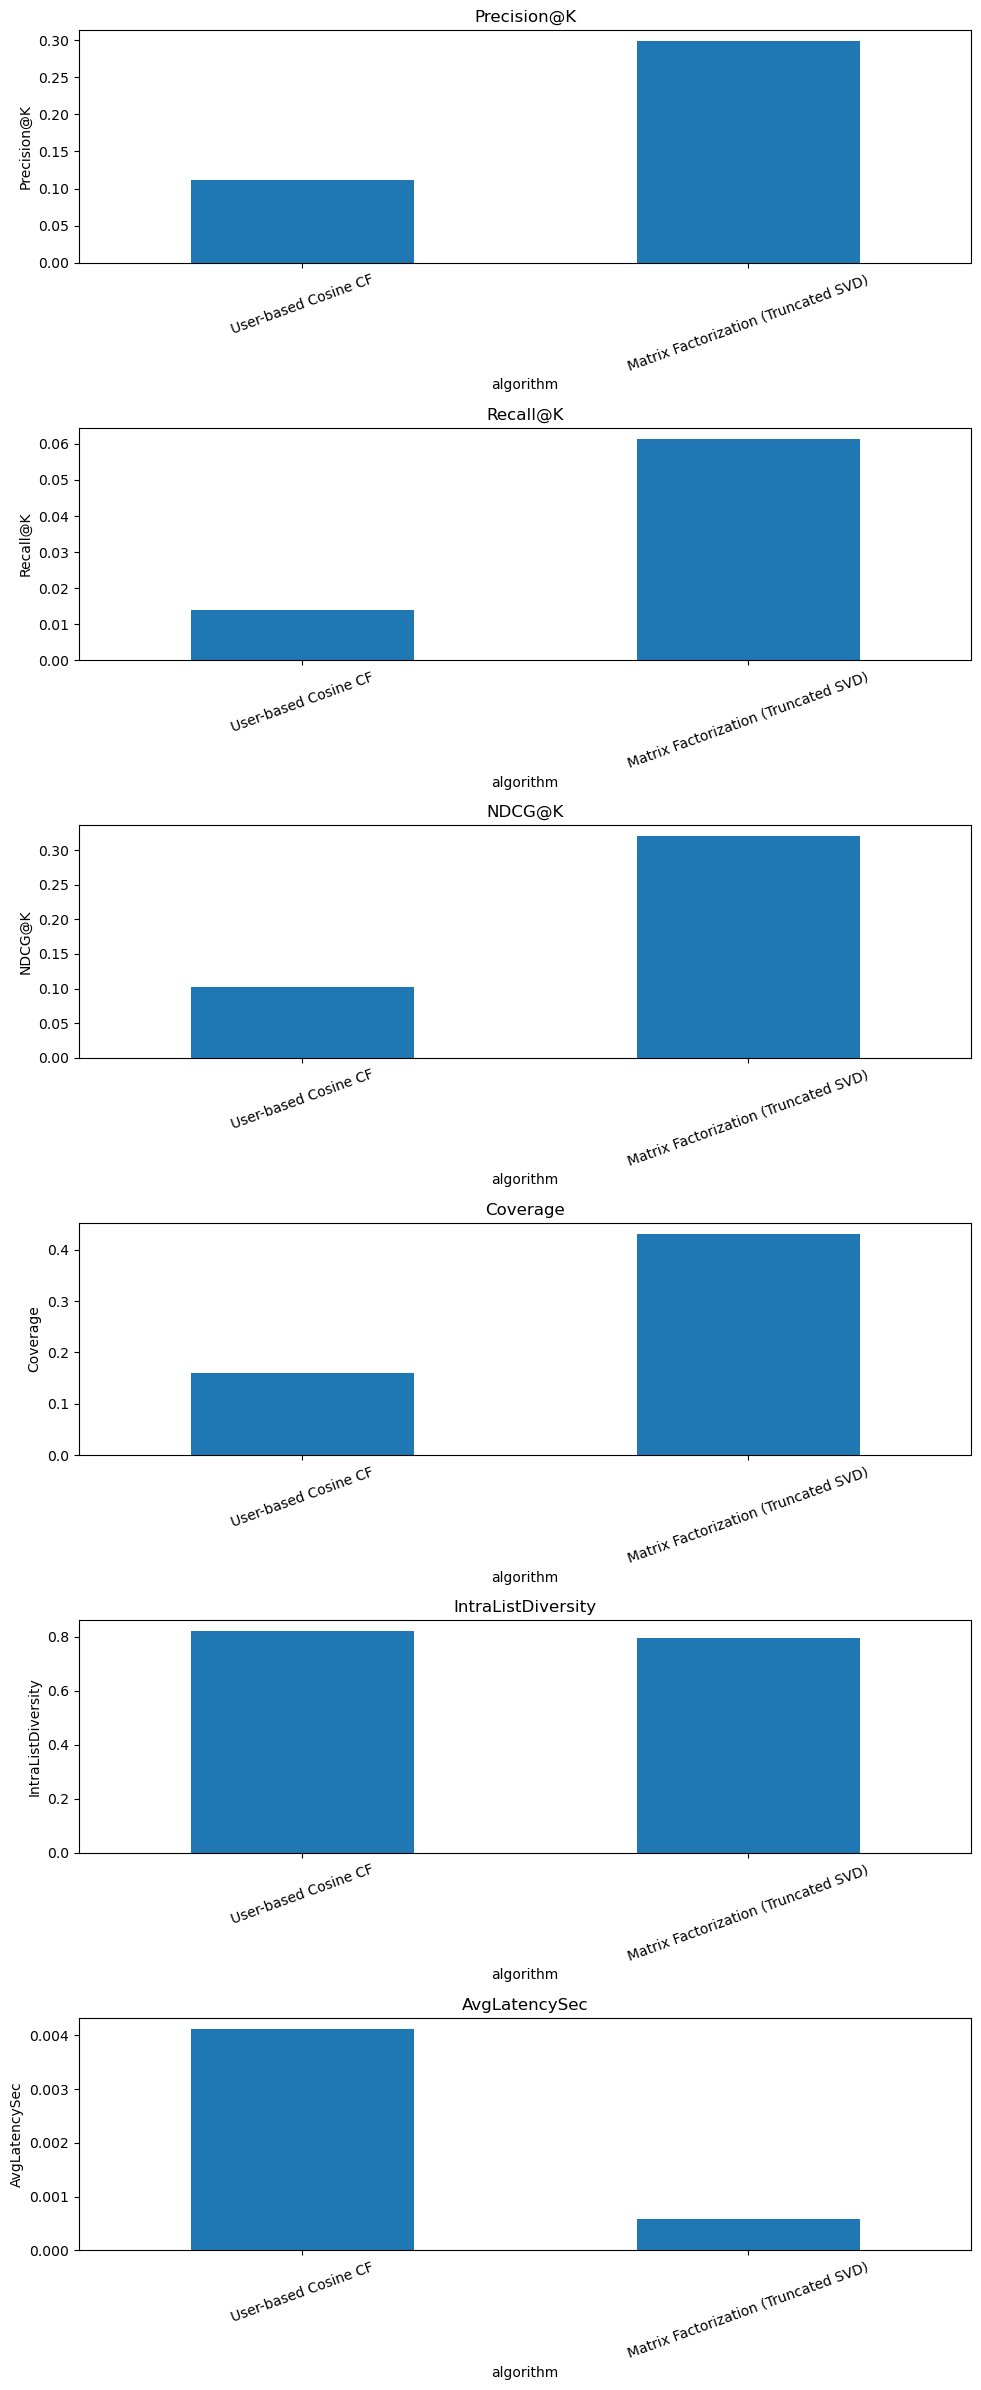

In [27]:

plot_df = results_df.set_index("algorithm")

metrics_to_plot = [
    "Precision@K",
    "Recall@K",
    "NDCG@K",
    "Coverage",
    "IntraListDiversity",
    "AvgLatencySec"
]

fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 4 * len(metrics_to_plot)))

for ax, metric in zip(axes, metrics_to_plot):
    plot_df[metric].plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()



## Cell 23: Interpreting the results

Use this section to write down your observations after running the notebook.

Questions to answer:
- Which algorithm has better top-K ranking quality?
- Which one covers more of the catalog?
- Which one appears more diverse?
- Which one recommends more popular movies?
- Which one is better suited for a transparent interactive UI?

A typical pattern is:
- user-based CF is easier to explain
- matrix factorization often has stronger ranking quality
- the methods may differ in coverage, diversity, and popularity concentration



## Cell 24: Suggested next steps

Once this notebook works, good next steps are:

1. Add **item-based collaborative filtering**
2. Add **novelty** and **popularity-bucket exposure** metrics
3. Add a **2D movie map** using genres, tags, or latent embeddings
4. Add lightweight explanation panels:
   - "recommended because similar users liked it"
   - "recommended because it aligns with your latent factors"
5. Cache recommendation outputs for a future Flask/D3 frontend
